## Тема 1. Моделирование геометрической вероятности: Задача о встрече

**Условие:** Два человека договорились встретиться в кафе между 12:00 и 13:00. 
Каждый приходит в случайный момент времени и ждет другого ровно 15 минут.
Нужно найти вероятность их встречи теоретически и смоделировать процесс.

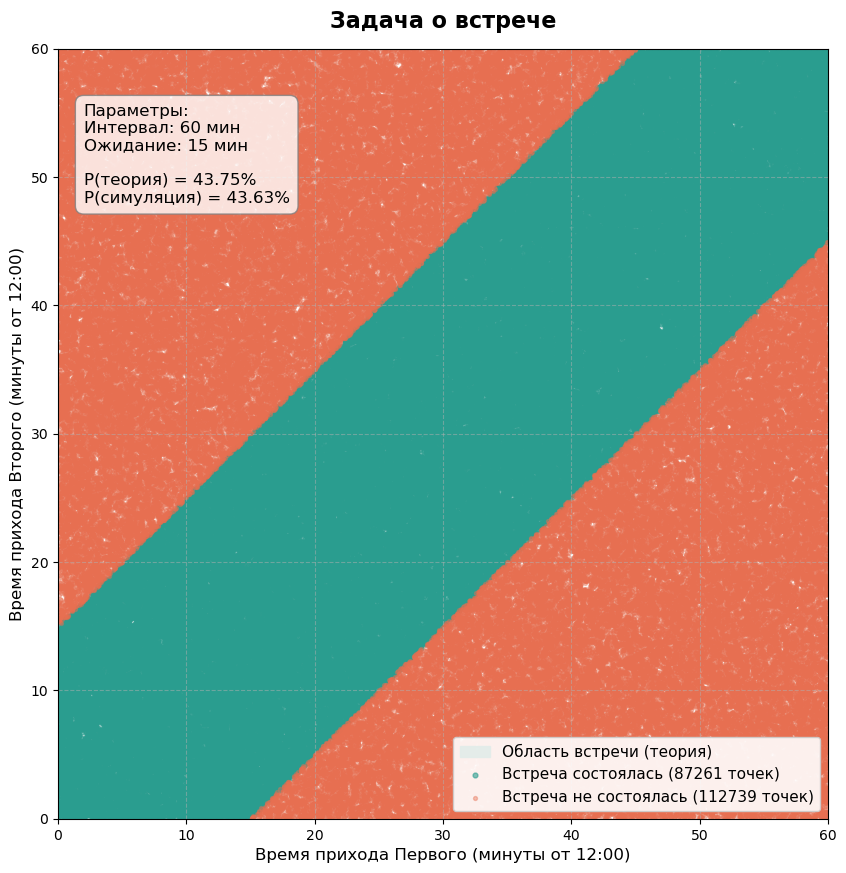

In [10]:
import matplotlib.pyplot as plt
import numpy as np

TOTAL_TIME = 60
WAIT_TIME = 15
NUM_SAMPLES = 200000

np.random.default_rng()

x_samples = np.random.uniform(0, TOTAL_TIME, NUM_SAMPLES)
y_samples = np.random.uniform(0, TOTAL_TIME, NUM_SAMPLES)

success_mask = np.abs(x_samples - y_samples) <= WAIT_TIME

successful_meetings = np.sum(success_mask)
experimental_prob = successful_meetings / NUM_SAMPLES

theoretical_prob = 1 - ((TOTAL_TIME - WAIT_TIME) / TOTAL_TIME) ** 2

plt.figure(figsize=(10, 10))

x_grid = np.linspace(0, TOTAL_TIME, 500)
y_upper = np.minimum(x_grid + WAIT_TIME, TOTAL_TIME)
y_lower = np.maximum(x_grid - WAIT_TIME, 0)

plt.fill_between(x_grid, y_lower, y_upper, color='#e2ece9', alpha=0.9, label='Область встречи (теория)')

plt.scatter(x_samples[success_mask], y_samples[success_mask], 
            color='#2a9d8f', s=12, alpha=0.6, label=f'Встреча состоялась ({successful_meetings} точек)')
plt.scatter(x_samples[~success_mask], y_samples[~success_mask], 
            color='#e76f51', s=8, alpha=0.4, label=f'Встреча не состоялась ({NUM_SAMPLES - successful_meetings} точек)')

plt.title('Задача о встрече', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Время прихода Первого (минуты от 12:00)', fontsize=12)
plt.ylabel('Время прихода Второго (минуты от 12:00)', fontsize=12)

plt.xlim(0, TOTAL_TIME)
plt.ylim(0, TOTAL_TIME)
plt.xticks(np.arange(0, TOTAL_TIME + 1, 10))
plt.yticks(np.arange(0, TOTAL_TIME + 1, 10))
plt.grid(True, linestyle='--', alpha=0.5)

info_text = (f"Параметры:\n"
             f"Интервал: {TOTAL_TIME} мин\n"
             f"Ожидание: {WAIT_TIME} мин\n\n"
             f"P(теория) = {theoretical_prob*100:.2f}%\n"
             f"P(симуляция) = {experimental_prob*100:.2f}%")

plt.text(2, TOTAL_TIME - 12, info_text, fontsize=12, 
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray'))

plt.legend(loc='lower right', fontsize=11, framealpha=0.9)
plt.gca().set_aspect('equal', adjustable='box')

plt.show()